In [2]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append("..")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,  MultiLabelBinarizer, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.compose import ColumnTransformer
import joblib

from src.utils import numerical_cols, categorical_cols, target_reg, target_cls,  selected_features, selected_cat_cols, selected_num_cols


### Loading dataset

In [4]:
df = pd.read_csv(r"C:\projects\ml-pipeline\data\processed\feature_engineered_df.csv", encoding= 'utf-8')

In [5]:
df.head()

,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,...,Brand,Month,Year,Quarter,Profit_loss,CTR,Conversion_rate,Lead_Rate,Revenue_per_lead,Cost_per_click
0,social media,college students,21.0,"whatsapp, youtube",57804.0,6156.0,3616.0,2355.0,1867515.0,208.725,...,nykaa,4,2025,2,Profit,0.106498,0.382554,0.587394,516.458794,0.033906
1,paid ads,tier 2 city customers,18.0,youtube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,...,nykaa,4,2025,2,Profit,0.036176,0.408612,0.593496,530.820396,0.054450
2,influencer,youth,23.0,"google, whatsapp, youtube",15536.0,2182.0,952.0,755.0,197055.0,90.600,...,nykaa,1,2025,1,Profit,0.140448,0.346013,0.436297,206.990546,0.041522
3,email,working women,18.0,"facebook, instagram, youtube",88114.0,8413.0,2231.0,947.0,376906.0,249.070,...,nykaa,6,2025,2,Profit,0.095479,0.112564,0.265185,168.940385,0.029605
4,paid ads,college students,10.0,"facebook, instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,...,nykaa,12,2024,4,Profit,0.038639,0.336094,0.550361,251.600000,0.061074


In [5]:
df.shape

(166665, 23)

## Regression Model

In [5]:
# Splitting features and Target

In [5]:
X = df[selected_features]
Y_reg = df[target_reg]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_reg,
    test_size=0.3,
    random_state=42
)

In [7]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((116665, 6), (50000, 6), (116665,), (50000,))

In [8]:
selected_cat_cols = df[selected_features].select_dtypes(include='object').columns
selected_cat_cols

C:\Users\dell\AppData\Local\Temp\ipykernel_5720\804582863.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  selected_cat_cols = df[selected_features].select_dtypes(include='object').columns


Index(['Campaign_Type', 'Channel_Used', 'Brand'], dtype='str')

In [9]:
selected_num_cols= df[selected_features].select_dtypes(exclude='object').columns
selected_num_cols

Index(['Cost_per_click', 'Acquisition_Cost', 'Conversion_rate'], dtype='str')

In [10]:
x_train_cat = X_train[selected_cat_cols]
x_test_cat = X_test[selected_cat_cols]


In [11]:
x_train_num = X_train[selected_num_cols]
x_test_num=  X_test[selected_num_cols]

In [ ]:
# Encoding Features

In [135]:
# using Onehotencoder for Campaign_Type and Brand columns

In [12]:
ohe = OneHotEncoder(handle_unknown= 'ignore', sparse_output=False)

x_train_other_cat = pd.DataFrame (
    ohe.fit_transform(X_train[['Campaign_Type', 'Brand']]),
    columns = ohe.get_feature_names_out(),
    index = X_train.index)

X_test_other_cat = pd.DataFrame(
    ohe.transform(X_test[['Campaign_Type','Brand']]),
    columns=ohe.get_feature_names_out(),
    index=X_test.index)

In [82]:
# encoding Channel_Used column seperately using MultilabelBinazer

In [13]:
X_train_channel = X_train['Channel_Used'].str.split(', ')
X_test_channel = X_test['Channel_Used'].str.split(', ')

In [14]:
mlb = MultiLabelBinarizer()

In [15]:
x_train_channel = pd.DataFrame(
    mlb.fit_transform(X_train_channel),
    columns=mlb.classes_,
    index=X_train.index
)

x_test_channel = pd.DataFrame(
    mlb.transform(X_test_channel),
    columns=mlb.classes_,
    index=X_test.index
)


In [ ]:
# Scaling Features

In [17]:
## using robust scaler because numerical columns has outliers which can be handled by robust scaler

In [16]:
rs = RobustScaler()

X_train_num_scaled = pd.DataFrame(
    rs.fit_transform(x_train_num),
    columns=x_train_num.columns,
    index=x_train_num.index
)

X_test_num_scaled = pd.DataFrame(
    rs.transform(x_test_num),
    columns=x_test_num.columns,
    index=x_test_num.index
)

In [ ]:
# Combining features

In [17]:
X_train_final = pd.concat([X_train_num_scaled,x_train_other_cat, x_train_channel ], axis = 1)
X_test_final = pd.concat([X_test_num_scaled, X_test_other_cat, x_test_channel], axis=1)

#### LinearRegression

In [167]:
model = LinearRegression()

reg= model.fit(X_train_final, Y_train)
reg.coef_
reg.intercept_

y_pred = model.predict(X_test_final)


In [168]:
print("MSE:", round(mean_squared_error(Y_test, y_pred),2))
print("MAE:", round( mean_absolute_error(Y_test, y_pred),2))
print("R2:", round(r2_score(Y_test, y_pred),2))

MSE: 172489294762.6
MAE: 288347.64
R2: 0.24


#### Random Forest Regressor

In [18]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=10, 
                              min_samples_leaf=4, random_state=42, n_jobs=1, )

rf_reg = model.fit(X_train_final , Y_train)

y_train_pred = model.predict(X_train_final)
y_pred = model.predict(X_test_final)



In [36]:
print(f"Train R2 : {r2_score(Y_train, y_train_pred):.4f}")
print(f"Test  R2 : {r2_score(Y_test, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(Y_test, y_pred):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(Y_test, y_pred)):.2f}")

Train R2 : 0.7503
Test  R2 : 0.7030
MAE      : 168540.56
RMSE     : 258839.44


#### XG Boost Regressor

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [19]:
xgb_reg = XGBRegressor(n_estimators= 200, learning_rate= 0.03, max_depth = 5,
                     min_child_weight=5, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1)

xgb = xgb_reg.fit(X_train_final, Y_train)

y_train_pred= xgb_reg.predict(X_train_final)
y_test_pred = xgb_reg.predict(X_test_final)


In [20]:
print(f"Train R2 : {r2_score(Y_train, y_train_pred):.4f}")
print(f"Test  R2 : {r2_score(Y_test, y_test_pred):.4f}")
print(f"MAE      : {mean_absolute_error(Y_test, y_test_pred):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(Y_test, y_test_pred)):.2f}")

Train R2 : 0.7102
Test  R2 : 0.6971
MAE      : 171707.40
RMSE     : 261402.88


In [222]:
### REGRESSION RESULT — Revenue Prediction
### Best Model   : XGBoost
### Train R2     : 0.7102
### Test R2      : 0.6971
### MAE          : 171,707
### RMSE         : 261,402
### Overfit gap  : 0.0059 — acceptable

## Classification Model

In [111]:
# Splitting Features

In [6]:
X = df[selected_features]
y_cls = df[target_cls]


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y_cls,
    test_size=0.3,
    random_state=42, stratify=y_cls
)

In [8]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((116665, 6), (50000, 6), (116665,), (50000,))

In [9]:
selected_cat_cols = df[selected_features].select_dtypes(include='object').columns
selected_cat_cols

C:\Users\dell\AppData\Local\Temp\ipykernel_5552\804582863.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  selected_cat_cols = df[selected_features].select_dtypes(include='object').columns


Index(['Campaign_Type', 'Channel_Used', 'Brand'], dtype='str')

In [10]:
selected_num_cols= df[selected_features].select_dtypes(exclude='object').columns
selected_num_cols

Index(['Cost_per_click', 'Acquisition_Cost', 'Conversion_rate'], dtype='str')

In [11]:
x_train_cat = X_train[selected_cat_cols]
x_test_cat = X_train[selected_cat_cols]

In [12]:
x_train_num = X_train[selected_num_cols]
x_test_num=  X_test[selected_num_cols]

In [ ]:
# Encoding Features

In [13]:
ohe = OneHotEncoder(handle_unknown= 'ignore', sparse_output=False)

x_train_other_cat = pd.DataFrame (
    ohe.fit_transform(X_train[['Campaign_Type', 'Brand']]),
    columns = ohe.get_feature_names_out(),
    index = X_train.index)

X_test_other_cat = pd.DataFrame(
    ohe.transform(X_test[['Campaign_Type','Brand']]),
    columns=ohe.get_feature_names_out(),
    index=X_test.index)

In [14]:
X_train_channel = X_train['Channel_Used'].str.split(', ')
X_test_channel = X_test['Channel_Used'].str.split(', ')

In [15]:
mlb = MultiLabelBinarizer()

x_train_channel = pd.DataFrame(
    mlb.fit_transform(X_train_channel),
    columns=mlb.classes_,
    index=X_train.index
)

x_test_channel = pd.DataFrame(
    mlb.transform(X_test_channel),
    columns=mlb.classes_,
    index=X_test.index
)


In [15]:
# Scaling Features

In [16]:
rs = RobustScaler()

X_train_num_scaled = pd.DataFrame(
    rs.fit_transform(x_train_num),
    columns=x_train_num.columns,
    index=x_train_num.index
)

X_test_num_scaled = pd.DataFrame(
    rs.transform(x_test_num),
    columns=x_test_num.columns,
    index=x_test_num.index
)

In [17]:
# Combining Features

In [17]:
X_train_final = pd.concat([X_train_num_scaled,x_train_other_cat, x_train_channel ], axis = 1)
X_test_final = pd.concat([X_test_num_scaled, X_test_other_cat, x_test_channel], axis=1)

####  Logistic Regression

In [19]:
model = LogisticRegression(class_weight='balanced')

cls = model.fit(X_train_final, Y_train)

y_pred= model.predict(X_test_final)


In [20]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Accuracy: 0.8807
              precision    recall  f1-score   support

        Loss       0.70      0.84      0.76     11367
      Profit       0.95      0.89      0.92     38633

    accuracy                           0.88     50000
   macro avg       0.82      0.87      0.84     50000
weighted avg       0.89      0.88      0.88     50000



#### Random Forest Classifier

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [56]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, 
                               min_samples_leaf=4, random_state=42, n_jobs=1)

rf_cls = model.fit(X_train_final, Y_train)

y_train_pred = model.predict(X_train_final)
y_test_pred = model.predict(X_test_final)


In [57]:
print("Accuracy:", accuracy_score(Y_test, y_test_pred))
print(classification_report(Y_test, y_test_pred))
print(confusion_matrix(Y_test, y_test_pred))


Accuracy: 0.89962
              precision    recall  f1-score   support

        Loss       0.82      0.71      0.76     11367
      Profit       0.92      0.95      0.94     38633

    accuracy                           0.90     50000
   macro avg       0.87      0.83      0.85     50000
weighted avg       0.90      0.90      0.90     50000

[[ 8103  3264]
 [ 1755 36878]]


#### XG boost Classifier

In [ ]:
## Encoding target variable for XGB classifier

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
le= LabelEncoder()

Y_train_encoded = le.fit_transform(Y_train)
Y_test_encoded= le.transform(Y_test)


print(le.classes_)                            # ['Loss' 'Profit']
print(Y_train_encoded[:5]) 

['Loss' 'Profit']
[1 1 1 0 1]


In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

In [21]:
xgb_cls = XGBClassifier()

xgb= xgb_cls.fit(X_train_final, Y_train_encoded)

y_train_pred = xgb_cls.predict(X_train_final)
y_test_pred = xgb_cls.predict(X_test_final)


In [22]:
print("Accuracy:", accuracy_score(Y_test_encoded, y_test_pred))
print(classification_report(Y_test_encoded, y_test_pred))
print(confusion_matrix(Y_test_encoded, y_test_pred))

Accuracy: 0.90114
              precision    recall  f1-score   support

           0       0.82      0.73      0.77     11367
           1       0.92      0.95      0.94     38633

    accuracy                           0.90     50000
   macro avg       0.87      0.84      0.85     50000
weighted avg       0.90      0.90      0.90     50000

[[ 8284  3083]
 [ 1860 36773]]


In [136]:
# CLASSIFICATION RESULT — Profit/Loss Prediction
# Best Model     : XGBoost
# Test Accuracy  : 90%
# Loss F1        : 0.77
# Profit F1      : 0.94
# Macro F1       : 0.85

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:

y_pred      = xgb_cls.predict(X_test_final)
y_pred_prob = xgb_cls.predict_proba(X_test_final)[:, 1]

acc     = accuracy_score(Y_test_encoded, y_pred)
roc_auc = roc_auc_score(Y_test_encoded, y_pred_prob)

In [26]:
print("\n── Classification Evaluation ────────────────────────")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"\n{classification_report(Y_test_encoded, y_pred, target_names=le.classes_)}")


── Classification Evaluation ────────────────────────
Accuracy : 0.9011
ROC AUC  : 0.9555

              precision    recall  f1-score   support

        Loss       0.82      0.73      0.77     11367
      Profit       0.92      0.95      0.94     38633

    accuracy                           0.90     50000
   macro avg       0.87      0.84      0.85     50000
weighted avg       0.90      0.90      0.90     50000



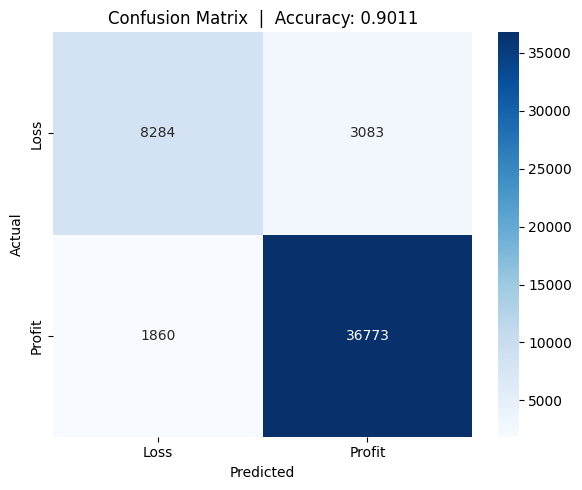

In [27]:
# confusion matrix plot
cm = confusion_matrix(Y_test_encoded, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix  |  Accuracy: {acc:.4f}')
plt.tight_layout()

plt.show()

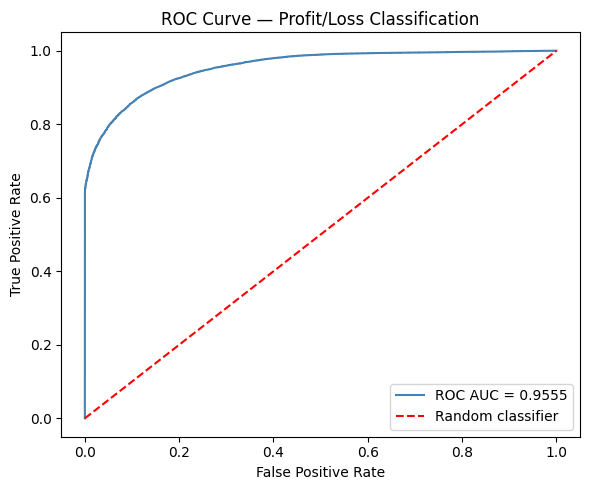

✅ Classification plots saved!


In [28]:
# ROC curve plot
fpr, tpr, _ = roc_curve(Y_test_encoded, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Profit/Loss Classification')
plt.legend()
plt.tight_layout()

plt.show()
print("✅ Classification plots saved!")

In [ ]:
#Note on model disagreement:
#Regression and Classification models may occasionally disagree.
#This is expected behavior — they answer different questions.

#Regression  → predicts raw Revenue generated
#Classification → predicts overall profitability 
                # accounting for all campaign costs
               #  beyond Acquisition_Cost

#When they disagree → trust Classification for go/no-go decisions
                #  → use Regression for revenue forecasting only